<a href="https://colab.research.google.com/github/JadoHR/warehouse-location-optimization/blob/main/warehouse_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚚 Warehouse Location Optimization — Indonesia

This project explores the **warehouse location optimization problem** for a logistics network across Indonesia. The goal is to determine warehouse locations that minimize total distribution distance and logistics costs while efficiently serving demand across multiple cities.

## Methods
- **Haversine Distance** – calculates real-world distances between cities using geographic coordinates.
- **K-Means Clustering** – groups cities based on geographic proximity and demand patterns.
- **Greedy Warehouse Selection** – iteratively selects warehouse locations that reduce total distribution distance.
- **Geospatial Visualization** – maps demand distribution and optimal warehouse coverage.

## Dataset
The dataset includes **30 Indonesian cities** with information on:
- geographic coordinates  
- demand estimates  
- population data  
- logistics cost indicators  

## Objective
Identify **efficient warehouse locations** to improve logistics performance and demonstrate practical **supply chain optimization techniques**.

## 1. Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.style.use('seaborn-v0_8-whitegrid')

cities     = pd.read_csv('/indonesia_cities_demand.csv')
warehouses = pd.read_csv('/warehouse_candidates.csv')

print(f'Cities          : {len(cities)}')
print(f'Warehouse Candidates: {len(warehouses)}')
print(f'Total National Demand: {cities["demand_units"].sum():,} units')
cities.head()

Cities          : 30
Warehouse Candidates: 10
Total National Demand: 185,500 units


,location_id,city,province,island,latitude,longitude,demand_units,population_2023,gdp_per_capita_million_idr,distance_to_nearest_port_km,logistics_cost_index
0,L001,Central Jakarta,DKI Jakarta,Java,-6.1862,106.8063,15000,1200000,185.5,5,1.00
1,L002,West Jakarta,DKI Jakarta,Java,-6.1802,106.7470,12000,980000,175.2,8,1.00
2,L003,East Jakarta,DKI Jakarta,Java,-6.2251,106.9004,13500,1150000,168.3,12,1.05
3,L004,South Jakarta,DKI Jakarta,Java,-6.2607,106.8106,11000,1050000,190.1,10,1.00
4,L005,North Jakarta,DKI Jakarta,Java,-6.1213,106.8997,9000,850000,155.8,2,0.95


## 2. Indonesia Demand Map

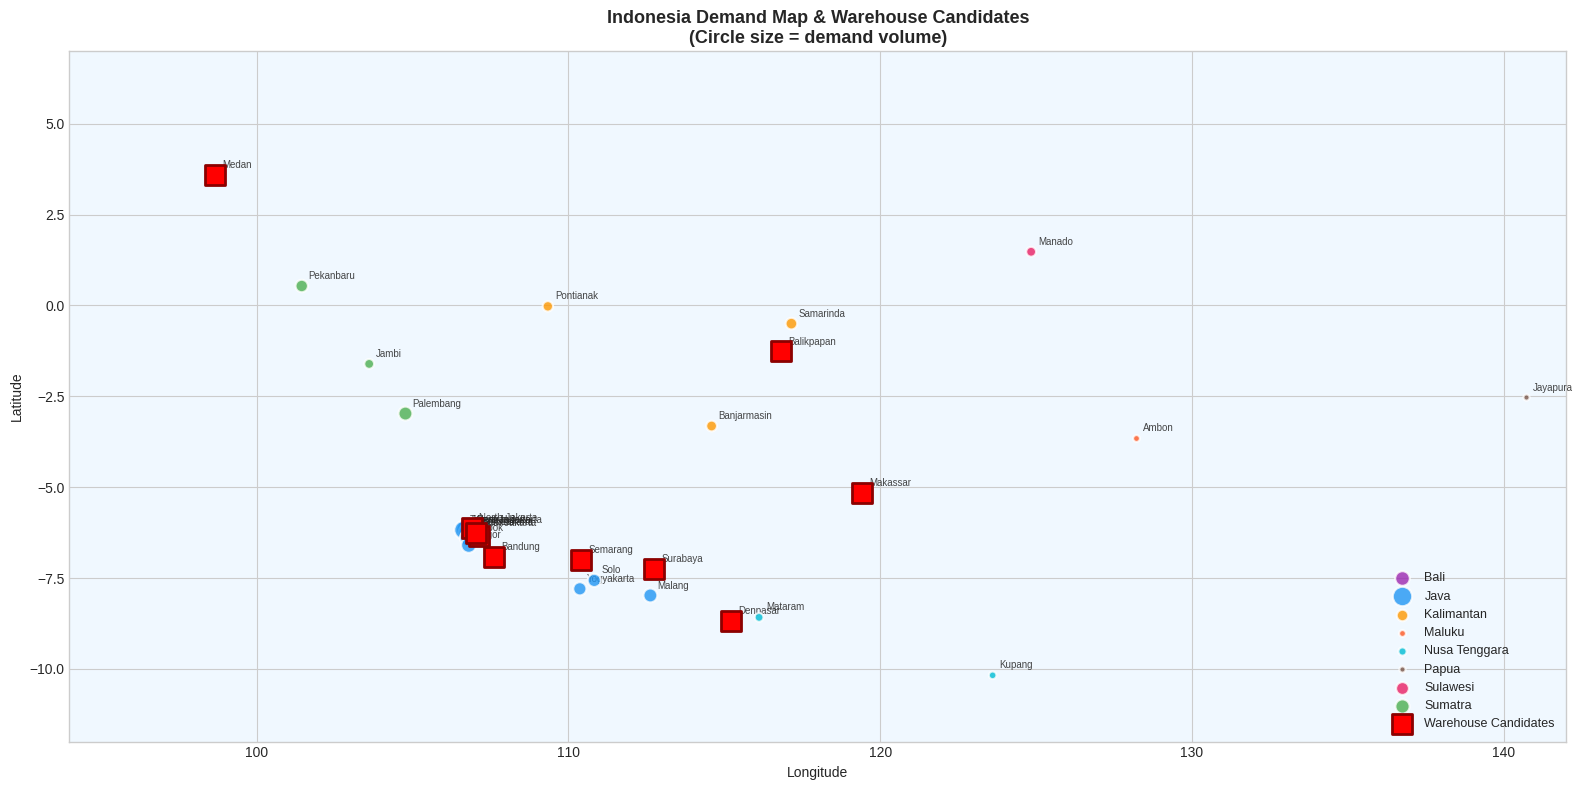

In [ ]:
island_colors = {
    'Java':         '#2196F3',
    'Sumatra':      '#4CAF50',
    'Kalimantan':   '#FF9800',
    'Sulawesi':     '#E91E63',
    'Bali':         '#9C27B0',
    'Nusa Tenggara':'#00BCD4',
    'Maluku':       '#FF5722',
    'Papua':        '#795548'
}

fig, ax = plt.subplots(figsize=(16, 8))

for island, group in cities.groupby('island'):
    ax.scatter(group['longitude'], group['latitude'],
               s=group['demand_units'] / 50,
               c=island_colors.get(island, 'gray'),
               alpha=0.8, edgecolors='white', linewidth=1.5,
               label=island, zorder=5)

for _, row in cities.iterrows():
    ax.annotate(row['city'], (row['longitude'], row['latitude']),
                textcoords='offset points', xytext=(5, 5), fontsize=7, alpha=0.85)

ax.scatter(warehouses['longitude'], warehouses['latitude'],
           marker='s', s=200, c='red', zorder=10,
           label='Warehouse Candidates', edgecolors='darkred', linewidth=2)

ax.set_xlim(94, 142)
ax.set_ylim(-12, 7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Indonesia Demand Map & Warehouse Candidates\n(Circle size = demand volume)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_facecolor('#f0f8ff')

plt.tight_layout()
plt.savefig('demand_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Haversine Distance Function

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    """Calculate the great-circle distance between two points on Earth (km)."""
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def compute_distance_matrix(cities_df, warehouses_df):
    """Build a distance matrix (cities × warehouses) in km."""
    dist = pd.DataFrame(index=cities_df['city'], columns=warehouses_df['city'])
    for _, c in cities_df.iterrows():
        for _, w in warehouses_df.iterrows():
            dist.loc[c['city'], w['city']] = haversine(
                c['latitude'], c['longitude'], w['latitude'], w['longitude'])
    return dist.astype(float)

dist_matrix = compute_distance_matrix(cities, warehouses)
print('=== DISTANCE FROM CENTRAL JAKARTA TO ALL WAREHOUSE CANDIDATES (km) ===')
print(dist_matrix.loc['Central Jakarta'].sort_values().round(1).to_string())

=== DISTANCE FROM CENTRAL JAKARTA TO ALL WAREHOUSE CANDIDATES (km) ===
city
North Jakarta      12.6
Cibitung           28.1
Cikarang           41.3
Bandung           121.1
Semarang          409.2
Surabaya          667.3
Denpasar          967.1
Balikpapan       1239.0
Makassar         1401.8
Medan            1413.7


## 4. K-Means Clustering of Cities

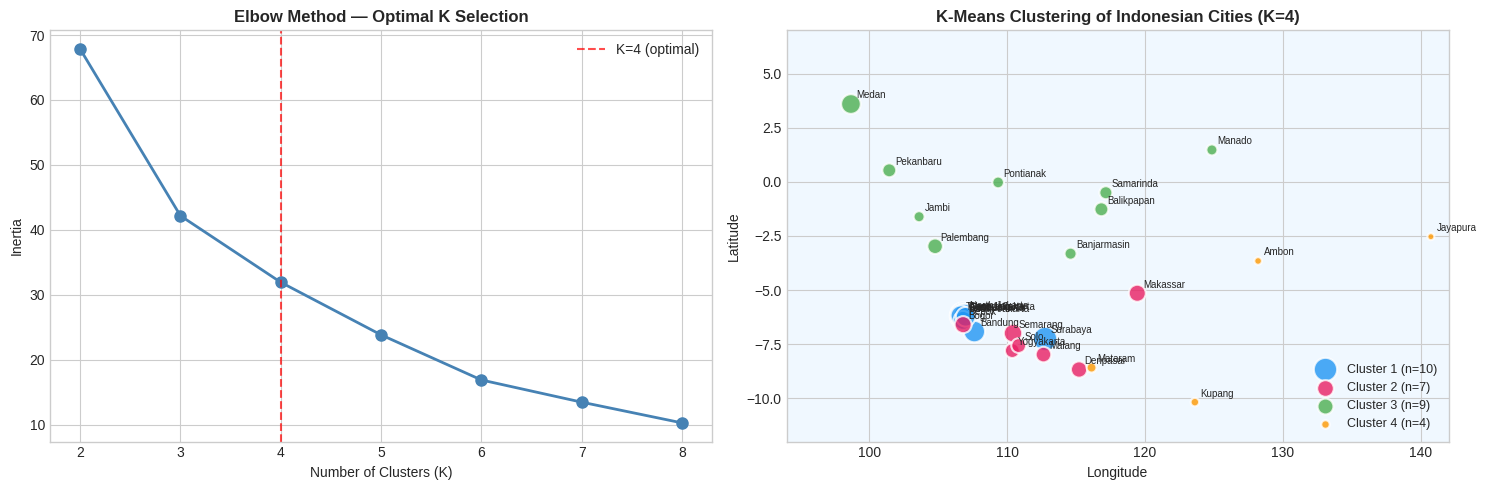

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = cities[['latitude', 'longitude', 'demand_units', 'logistics_cost_index']].copy()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (optimal)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Optimal K Selection', fontweight='bold')
axes[0].legend()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cities['cluster'] = kmeans.fit_predict(X_scaled)

cluster_colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']
for c_id in range(4):
    group = cities[cities['cluster'] == c_id]
    axes[1].scatter(group['longitude'], group['latitude'],
                    s=group['demand_units'] / 40, c=cluster_colors[c_id],
                    alpha=0.8, edgecolors='white', linewidth=1.5,
                    label=f'Cluster {c_id+1} (n={len(group)})')
    for _, row in group.iterrows():
        axes[1].annotate(row['city'], (row['longitude'], row['latitude']),
                         textcoords='offset points', xytext=(4, 4), fontsize=7)

axes[1].set_xlim(94, 142)
axes[1].set_ylim(-12, 7)
axes[1].set_facecolor('#f0f8ff')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('K-Means Clustering of Indonesian Cities (K=4)', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('clustering_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Greedy Warehouse Selection

In [ ]:
def compute_total_cost(selected_ids, dist_matrix, cities_df, warehouses_df, cost_per_km=0.5):
    """
    Total logistics cost = transport cost + fixed warehouse cost.
    Each city is served by its nearest selected warehouse.
    """
    wh_names      = warehouses_df.loc[selected_ids, 'city'].values
    min_dist      = dist_matrix[wh_names].min(axis=1)
    city_demand   = cities_df.set_index('city')['demand_units']
    transport_cost = (min_dist * city_demand * cost_per_km).sum()
    fixed_cost     = warehouses_df.loc[selected_ids, 'fixed_cost_million_idr'].sum() * 1_000_000
    return transport_cost + fixed_cost, transport_cost, fixed_cost

selected  = []
all_wh    = list(warehouses.index)
greedy_log = []

for step in range(4):
    best_wh, best_cost = None, float('inf')
    for wh_idx in all_wh:
        if wh_idx in selected:
            continue
        total, _, _ = compute_total_cost(selected + [wh_idx], dist_matrix, cities, warehouses)
        if total < best_cost:
            best_cost, best_wh = total, wh_idx
    selected.append(best_wh)
    total, transport, fixed = compute_total_cost(selected, dist_matrix, cities, warehouses)
    greedy_log.append({
        'Step': step + 1,
        'Warehouse Added':         warehouses.loc[best_wh, 'city'],
        'Total Cost (Billion IDR)': round(total / 1e9, 2),
        'Transport Cost':           round(transport / 1e9, 2),
        'Fixed Cost':               round(fixed / 1e9, 2)
    })
    print(f'Step {step+1}: Added {warehouses.loc[best_wh, "city"]} → Total Cost: IDR {total/1e9:.2f}B')

greedy_df = pd.DataFrame(greedy_log)
print('\n=== GREEDY SELECTION SUMMARY ===')
print(greedy_df.to_string(index=False))

Step 1: Added Semarang → Total Cost: IDR 3.05B
Step 2: Added Cibitung → Total Cost: IDR 6.23B
Step 3: Added Makassar → Total Cost: IDR 9.42B
Step 4: Added Balikpapan → Total Cost: IDR 12.92B

=== GREEDY SELECTION SUMMARY ===
 Step Warehouse Added  Total Cost (Billion IDR)  Transport Cost  Fixed Cost
    1        Semarang                      3.05            0.05         3.0
    2        Cibitung                      6.23            0.03         6.2
    3        Makassar                      9.42            0.02         9.4
    4      Balikpapan                     12.92            0.02        12.9


## 6. Optimal Warehouse Map

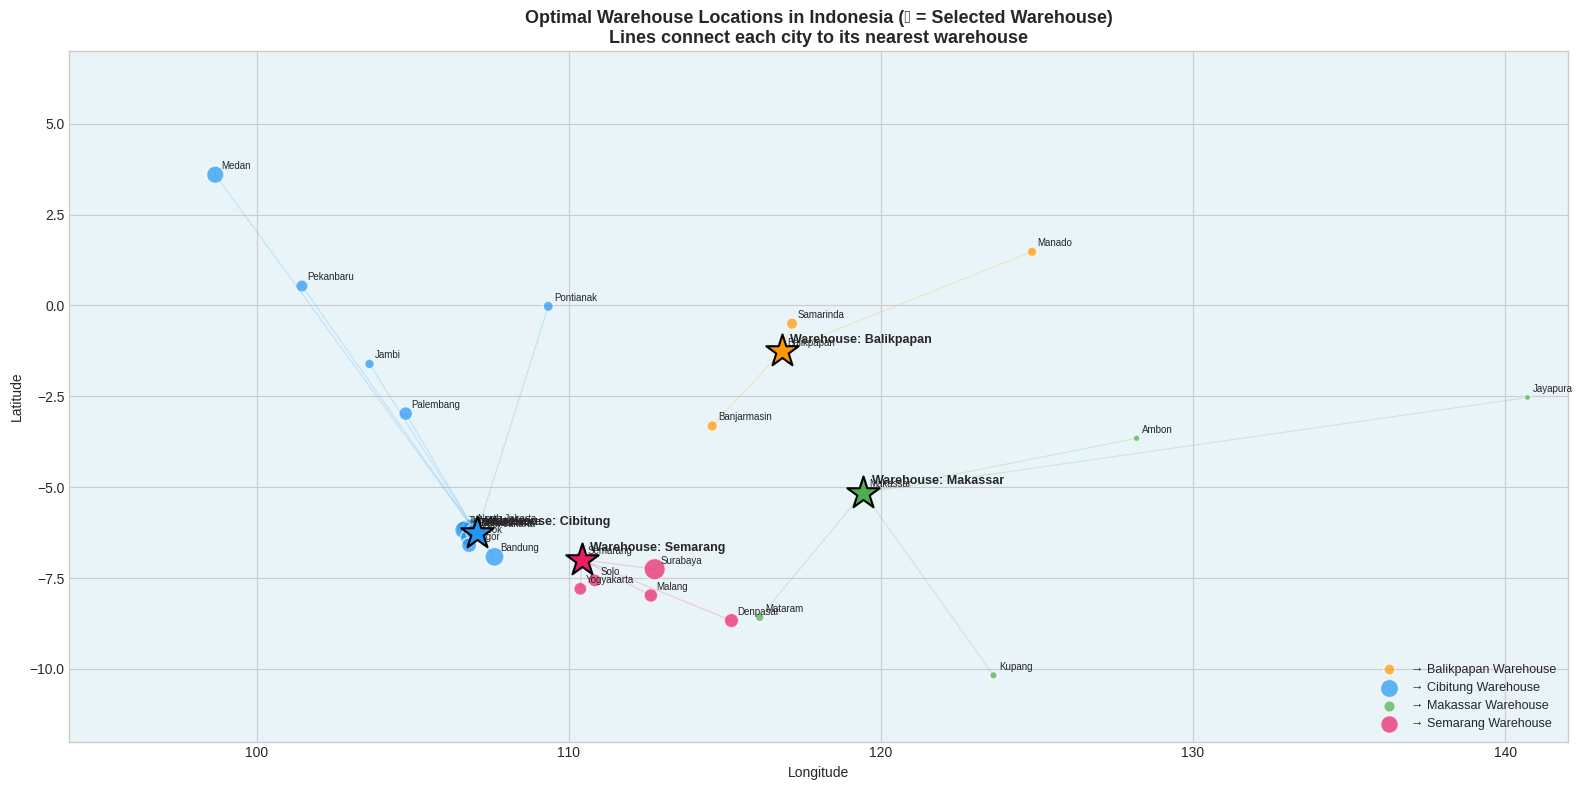

In [ ]:
selected_wh   = warehouses.loc[selected]
wh_names_sel  = selected_wh['city'].values
cities['assigned_warehouse'] = dist_matrix[wh_names_sel].idxmin(axis=1).values

wh_color_map = dict(zip(wh_names_sel, ['#E91E63', '#2196F3', '#4CAF50', '#FF9800']))

fig, ax = plt.subplots(figsize=(16, 8))

for wh_name, group in cities.groupby('assigned_warehouse'):
    color = wh_color_map.get(wh_name, 'gray')
    ax.scatter(group['longitude'], group['latitude'],
               s=group['demand_units'] / 50, c=color, alpha=0.7,
               edgecolors='white', linewidth=1.2, label=f'→ {wh_name} Warehouse')
    for _, row in group.iterrows():
        ax.annotate(row['city'], (row['longitude'], row['latitude']),
                    textcoords='offset points', xytext=(4, 4), fontsize=7)

for _, city_row in cities.iterrows():
    wh_row = warehouses[warehouses['city'] == city_row['assigned_warehouse']].iloc[0]
    ax.plot([city_row['longitude'], wh_row['longitude']],
            [city_row['latitude'],  wh_row['latitude']],
            color=wh_color_map.get(city_row['assigned_warehouse'], 'gray'),
            alpha=0.2, linewidth=0.8)

for _, wh_row in selected_wh.iterrows():
    color = wh_color_map.get(wh_row['city'], 'gray')
    ax.scatter(wh_row['longitude'], wh_row['latitude'],
               marker='*', s=600, c=color, zorder=10, edgecolors='black', linewidth=1.5)
    ax.annotate(f"Warehouse: {wh_row['city']}", (wh_row['longitude'], wh_row['latitude']),
                textcoords='offset points', xytext=(6, 6), fontsize=9, fontweight='bold')

ax.set_xlim(94, 142)
ax.set_ylim(-12, 7)
ax.set_facecolor('#e8f4f8')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Optimal Warehouse Locations in Indonesia (★ = Selected Warehouse)\nLines connect each city to its nearest warehouse',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('optimal_warehouse_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cost Reduction Analysis

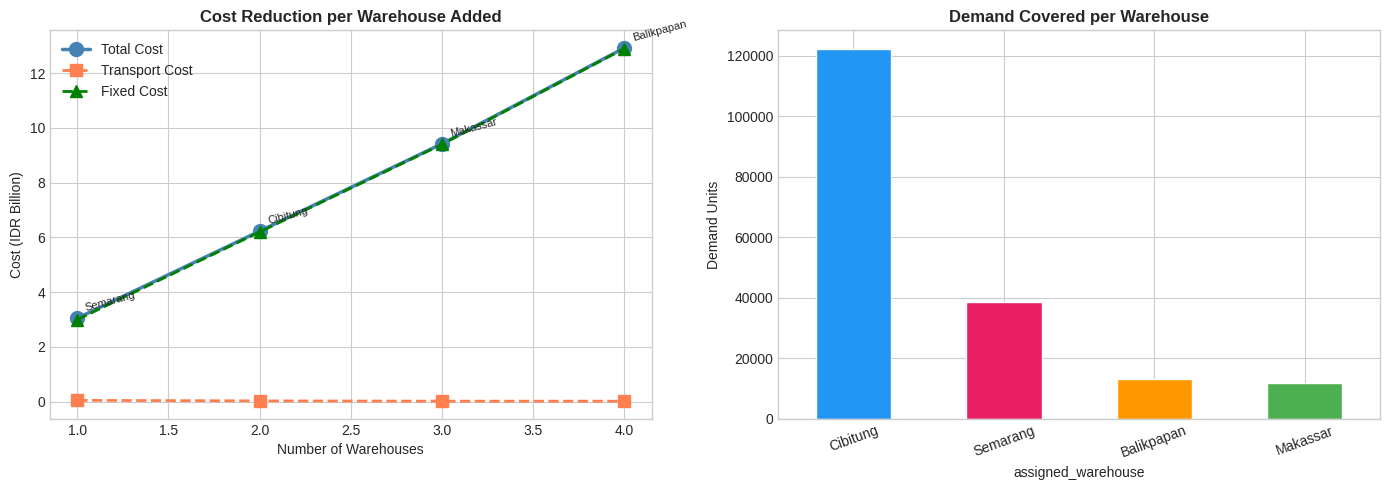

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

steps = greedy_df['Step']
axes[0].plot(steps, greedy_df['Total Cost (Billion IDR)'], 'o-', color='steelblue', linewidth=2.5, markersize=10, label='Total Cost')
axes[0].plot(steps, greedy_df['Transport Cost'],           's--', color='coral',    linewidth=2,   markersize=8,  label='Transport Cost')
axes[0].plot(steps, greedy_df['Fixed Cost'],               '^--', color='green',    linewidth=2,   markersize=8,  label='Fixed Cost')
for _, row in greedy_df.iterrows():
    axes[0].annotate(row['Warehouse Added'], (row['Step'], row['Total Cost (Billion IDR)']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8, rotation=15)
axes[0].set_xlabel('Number of Warehouses')
axes[0].set_ylabel('Cost (IDR Billion)')
axes[0].set_title('Cost Reduction per Warehouse Added', fontweight='bold')
axes[0].legend()

coverage = cities.groupby('assigned_warehouse')['demand_units'].sum().sort_values(ascending=False)
coverage.plot(kind='bar', ax=axes[1],
              color=[wh_color_map.get(c, 'gray') for c in coverage.index], edgecolor='white')
axes[1].set_title('Demand Covered per Warehouse', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Demand Units')

plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusion

In [ ]:
final_total, final_transport, final_fixed = compute_total_cost(selected, dist_matrix, cities, warehouses)
avg_dist = dist_matrix[wh_names_sel].min(axis=1).mean()

print('=' * 65)
print('RESULTS — INDONESIA WAREHOUSE LOCATION OPTIMIZATION')
print('=' * 65)
print('\n Selected Warehouses:')
for wh_city in selected_wh['city']:
    n_cities = (cities['assigned_warehouse'] == wh_city).sum()
    demand   = cities[cities['assigned_warehouse'] == wh_city]['demand_units'].sum()
    print(f'   {wh_city:25s} → serves {n_cities} cities, {demand:,} units demand')
print(f'\n Total Logistics Cost : IDR {final_total/1e9:.2f} billion/year')
print(f'  - Transport Cost     : IDR {final_transport/1e9:.2f} billion')
print(f'  - Fixed Warehouse Cost: IDR {final_fixed/1e9:.2f} billion')
print(f'\n Average Distance to Nearest Warehouse: {avg_dist:.1f} km')
print('\nAll output maps saved to data/')

RESULTS — INDONESIA WAREHOUSE LOCATION OPTIMIZATION

 Selected Warehouses:
   Semarang                  → serves 6 cities, 38,500 units demand
   Cibitung                  → serves 15 cities, 122,300 units demand
   Makassar                  → serves 5 cities, 11,700 units demand
   Balikpapan                → serves 4 cities, 13,000 units demand

 Total Logistics Cost : IDR 12.92 billion/year
  - Transport Cost     : IDR 0.02 billion
  - Fixed Warehouse Cost: IDR 12.90 billion

 Average Distance to Nearest Warehouse: 394.7 km

All output maps saved to data/
